Bài tập thực hành 3 (Bổ sung): Phân đoạn hình ảnh bằng K-Means (K-Means Image Segmentation)
Bài toán: Phân đoạn một hình ảnh cho trước thành K cụm bằng thuật toán K-means.



tải ảnh bằng pil

In [20]:
from PIL import Image, ImageOps

def resize_with_padding(img, target_size=(224, 224), color=(0, 0, 0)):
    target_w, target_h = target_size

    w, h = img.size

    scale = min(target_w / w, target_h / h)

    new_w = int(w * scale)
    new_h = int(h * scale)

    img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    return img

Image Shape: (168, 224, 3)
Pixels Shape: (37632, 3)

INITIAL CENTROIDS
--------------------------------------------------
C0: [183. 147.   0.]
C1: [68. 68. 13.]
C2: [178. 160.  68.]
C3: [41. 51. 43.]
C4: [233. 215.  36.]
C5: [213. 187.  28.]
C6: [92. 88. 12.]
C7: [58. 57.  7.]
C8: [225. 212. 166.]
C9: [51. 52. 49.]
C10: [220. 222. 146.]
C11: [218. 213. 160.]
C12: [217. 175.  51.]
C13: [98. 96. 24.]
C14: [253. 242. 129.]
C15: [66. 54. 12.]
C16: [17. 18. 13.]
C17: [34. 16.  0.]
C18: [30. 30. 10.]
C19: [77. 67. 14.]


ITERATION 1

PIXELS PER CLUSTER
Cluster 0: 914 pixels
Cluster 1: 779 pixels
Cluster 2: 3560 pixels
Cluster 3: 610 pixels
Cluster 4: 528 pixels
Cluster 5: 493 pixels
Cluster 6: 708 pixels
Cluster 7: 2063 pixels
Cluster 8: 1614 pixels
Cluster 9: 767 pixels
Cluster 10: 837 pixels
Cluster 11: 614 pixels
Cluster 12: 1060 pixels
Cluster 13: 3447 pixels
Cluster 14: 406 pixels
Cluster 15: 1585 pixels
Cluster 16: 10458 pixels
Cluster 17: 1617 pixels
Cluster 18: 4315 pixels
Cluster 19

Đã tải ảnh thành công.
Kích thước ma trận Pixels khảo sát: (40000, 3)

--- BẮT ĐẦU QUÁ TRÌNH KHẢO SÁT ELBOW ---
Khảo sát xong K = 2 | WCSS = 145296170.35
Khảo sát xong K = 3 | WCSS = 89369865.41
Khảo sát xong K = 4 | WCSS = 59208974.77
Khảo sát xong K = 5 | WCSS = 46491352.08
Khảo sát xong K = 6 | WCSS = 39466770.60
Khảo sát xong K = 7 | WCSS = 35564952.23
Khảo sát xong K = 8 | WCSS = 35050715.21

--- HOÀN THÀNH KHẢO SÁT, ĐANG HIỂN THỊ ĐỒ THỊ ---


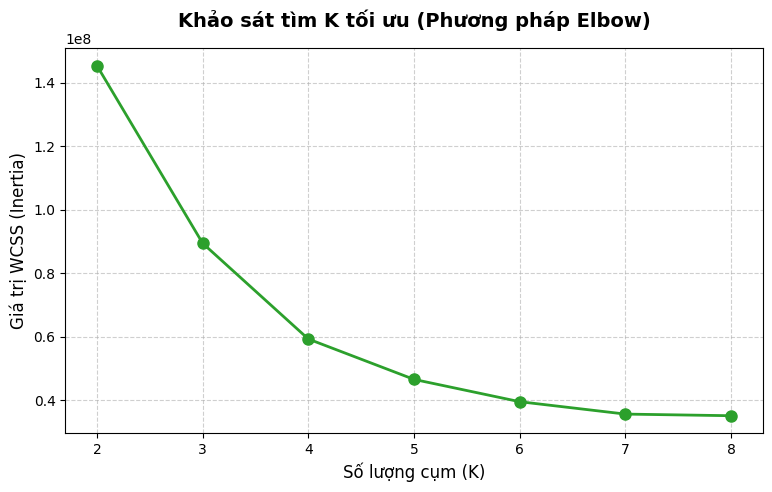

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ====================================================
# CLASS KMEANSIMAGE (Giữ nguyên cấu trúc của bạn)
# ====================================================
class KMeansImage:
    def __init__(self, k=4, max_iter=20, tol=1e-3):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.centroids = None
        self.labels = None

    def initialize_centroids(self, pixels):
        indices = np.random.choice(len(pixels), self.k, replace=False)
        self.centroids = pixels[indices].astype(float)

    def assign_clusters(self, pixels):
        distances = np.linalg.norm(pixels[:, np.newaxis] - self.centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        return labels

    def update_centroids(self, pixels, labels):
        new_centroids = []
        for k in range(self.k):
            cluster_pixels = pixels[labels == k]
            if len(cluster_pixels) == 0:
                centroid = self.centroids[k]
            else:
                centroid = cluster_pixels.mean(axis=0)
            new_centroids.append(centroid)
        return np.array(new_centroids)

    def fit(self, pixels):
        self.initialize_centroids(pixels)
        for iteration in range(self.max_iter):
            old_centroids = self.centroids.copy()
            labels = self.assign_clusters(pixels)
            self.labels = labels
            self.centroids = self.update_centroids(pixels, labels)
            
            shift = np.linalg.norm(self.centroids - old_centroids)
            if shift < self.tol:
                break
        return self

    # ==========================================
    # THÊM: Hàm tính WCSS (Tổng bình phương khoảng cách trong cụm)
    # ==========================================
    def compute_wcss(self, pixels):
        if self.centroids is None or self.labels is None:
            raise ValueError("Model chưa được huấn luyện bằng hàm .fit()")
        
        wcss = 0
        for k in range(self.k):
            cluster_pixels = pixels[self.labels == k]
            if len(cluster_pixels) > 0:
                # Bình phương khoảng cách từ các điểm tới tâm cụm k tương ứng
                wcss += np.sum((cluster_pixels - self.centroids[k]) ** 2)
        return wcss


# Giả định hàm resize của bạn (điều chỉnh kích thước nhỏ lại để chạy khảo sát cho nhanh)
def resize_with_padding(img):
    return img.resize((200, 200)) 


# ====================================================
# SCRIPT CHẠY KHẢO SÁT ELBOW ĐỘC LẬP
# ====================================================
if __name__ == "__main__":
    
    # 1. Đọc và tiền xử lý ảnh
    image_path = "f95aed8502aa31e208630a20b28c808c.jpg"
    
    try:
        img = Image.open(image_path).convert("RGB")
        img = resize_with_padding(img)  # Thu nhỏ ảnh để giảm số lượng pixel, giúp chạy thuật toán nhanh hơn
        img_array = np.array(img)
        pixels = img_array.reshape(-1, 3)
        print("Đã tải ảnh thành công.")
        print("Kích thước ma trận Pixels khảo sát:", pixels.shape)
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file {image_path}. Vui lòng kiểm tra lại tên file.")
        exit()

    # 2. Cấu hình giải khảo sát K
    # Khảo sát từ K = 2 đến K = 8 (khoảng tối ưu phổ biến cho nén màu ảnh)
    k_range = range(2, 9)  
    wcss_list = []

    print("\n--- BẮT ĐẦU QUÁ TRÌNH KHẢO SÁT ELBOW ---")
    
    for k in k_range:
        # Giảm max_iter xuống một chút (ví dụ: 15 vòng) để quét nhanh hơn, không cần hội tụ quá sâu
        model = KMeansImage(k=k, max_iter=15, tol=1e-2)
        
        # Chạy thuật toán để gom cụm
        model.fit(pixels)
        
        # Tính WCSS của cấu hình K hiện tại
        wcss = model.compute_wcss(pixels)
        wcss_list.append(wcss)
        
        print(f"Khảo sát xong K = {k} | WCSS = {wcss:.2f}")

    print("\n--- HOÀN THÀNH KHẢO SÁT, ĐANG HIỂN THỊ ĐỒ THỊ ---")
    
    # 3. Vẽ đồ thị biểu diễn Phương pháp khuỷu tay (Elbow Method)
    plt.figure(figsize=(9, 5))
    plt.plot(k_range, wcss_list, marker='o', markersize=8, linestyle='-', color='#2ca02c', linewidth=2)
    
    plt.title('Khảo sát tìm K tối ưu (Phương pháp Elbow)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Số lượng cụm (K)', fontsize=12)
    plt.ylabel('Giá trị WCSS (Inertia)', fontsize=12)
    plt.xticks(k_range)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Hiển thị đồ thị lên màn hình
    plt.show()

In [3]:
import numpy as np
from PIL import Image


class KMeansImage:

    def __init__(self, k=4, max_iter=20, tol=1e-3):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol

        self.centroids = None
        self.labels = None

    # ==========================================
    # Khởi tạo centroid ngẫu nhiên
    # ==========================================
    def initialize_centroids(self, pixels):

        indices = np.random.choice(
            len(pixels),
            self.k,
            replace=False
        )

        self.centroids = pixels[indices].astype(float)

        print("\nINITIAL CENTROIDS")
        print("-" * 50)

        for i, c in enumerate(self.centroids):
            print(f"C{i}: {c}")

    # ==========================================
    # Gán pixel vào centroid gần nhất
    # ==========================================
    def assign_clusters(self, pixels):

        distances = np.linalg.norm(
            pixels[:, np.newaxis] - self.centroids,
            axis=2
        )

        labels = np.argmin(distances, axis=1) # trả về cụm có khoảng cách gần nhất

        return labels

    # ==========================================
    # Tính centroid mới
    # ==========================================
    def update_centroids(self, pixels, labels):

        new_centroids = []

        for k in range(self.k):

            cluster_pixels = pixels[labels == k]

            if len(cluster_pixels) == 0:

                centroid = self.centroids[k]

            else:

                centroid = cluster_pixels.mean(axis=0)

            new_centroids.append(centroid)

        return np.array(new_centroids)

    # ==========================================
    # Huấn luyện
    # ==========================================
    def fit(self, pixels, watch_pixel=None):

        self.initialize_centroids(pixels)

        for iteration in range(self.max_iter):

            print("\n")
            print("=" * 60)
            print(f"ITERATION {iteration + 1}")
            print("=" * 60)

            old_centroids = self.centroids.copy()

            # -----------------------------
            # Assign Cluster
            # -----------------------------
            labels = self.assign_clusters(pixels)

            self.labels = labels

            print("\nPIXELS PER CLUSTER")

            for k in range(self.k):

                count = np.sum(labels == k)

                print(
                    f"Cluster {k}: {count} pixels"
                )

            # -----------------------------
            # Update Centroid
            # -----------------------------
            self.centroids = self.update_centroids(
                pixels,
                labels
            )

            print("\nCENTROID UPDATE")

            for i in range(self.k):

                print("\nCluster", i)

                print(
                    "Old:",
                    np.round(old_centroids[i], 2)
                )

                print(
                    "New:",
                    np.round(self.centroids[i], 2)
                )

            # -----------------------------
            # Kiểm tra hội tụ
            # -----------------------------
            shift = np.linalg.norm(
                self.centroids - old_centroids
            )

            print(
                f"\nCentroid Shift = {shift:.6f}"
            )

            if shift < self.tol:

                print("\nKMEANS CONVERGED")
                break

        return self

    # ==========================================
    # Nén ảnh
    # ==========================================
    def compress(self, pixels):

        labels = self.assign_clusters(pixels)

        compressed_pixels = (
            self.centroids[labels]
            .astype(np.uint8)
        )

        return compressed_pixels


# ====================================================
# MAIN
# ====================================================

# Đảm bảo hàm định nghĩa resize_with_padding của bạn đã tồn tại trước đó
# Ví dụ: def resize_with_padding(img): return img.resize((300, 300))

image_path = "f95aed8502aa31e208630a20b28c808c.jpg"

img = Image.open(image_path).convert("RGB")

# resize ảnh
img = resize_with_padding(img)

img_array = np.array(img)

h, w, c = img_array.shape

print("Image Shape:", img_array.shape)

# flatten
pixels = img_array.reshape(-1, 3)

print("Pixels Shape:", pixels.shape)

# nhập K
K = int(input("Nhap so cum K: "))

model = KMeansImage(
    k=K,
    max_iter=200
)

# ----------------------------------------------------
# BƯỚC ĐÃ ĐƯỢC SỬA: Huấn luyện mô hình trước khi nén
# ----------------------------------------------------
print("\n--- ĐANG HUẤN LUYỆN MÔ HÌNH K-MEANS ---")
model.fit(pixels)

print("\n--- TIẾN HÀNH NÉN ẢNH VÀ LƯU FILE ---")
compressed_pixels = model.compress(
    pixels
)

compressed_img = compressed_pixels.reshape(
    h,
    w,
    3
)

compressed_img = Image.fromarray(
    compressed_img
)

compressed_img.save(
    "compressed.jpg"
)

print("\nSaved: compressed.jpg")

Image Shape: (200, 200, 3)
Pixels Shape: (40000, 3)

--- ĐANG HUẤN LUYỆN MÔ HÌNH K-MEANS ---

INITIAL CENTROIDS
--------------------------------------------------
C0: [ 9. 18.  5.]
C1: [8. 7. 5.]
C2: [22. 19. 12.]
C3: [12. 15.  7.]


ITERATION 1

PIXELS PER CLUSTER
Cluster 0: 193 pixels
Cluster 1: 7175 pixels
Cluster 2: 30530 pixels
Cluster 3: 2102 pixels

CENTROID UPDATE

Cluster 0
Old: [ 9. 18.  5.]
New: [12.59 20.59  5.9 ]

Cluster 1
Old: [8. 7. 5.]
New: [6.45 5.62 4.18]

Cluster 2
Old: [22. 19. 12.]
New: [109.27  96.98  47.03]

Cluster 3
Old: [12. 15.  7.]
New: [14.09 13.37  7.21]

Centroid Shift = 122.295365


ITERATION 2

PIXELS PER CLUSTER
Cluster 0: 10183 pixels
Cluster 1: 6495 pixels
Cluster 2: 18187 pixels
Cluster 3: 5135 pixels

CENTROID UPDATE

Cluster 0
Old: [12.59 20.59  5.9 ]
New: [40.76 37.3  12.9 ]

Cluster 1
Old: [6.45 5.62 4.18]
New: [5.83 5.25 4.04]

Cluster 2
Old: [109.27  96.98  47.03]
New: [155.53 140.19  70.79]

Cluster 3
Old: [14.09 13.37  7.21]
New: [25.86 13.

In [4]:
print("\nFINAL CENTROIDS")

for i, c in enumerate(model.centroids):

    print(
        f"C{i}: {np.round(c,2)}"
    )


FINAL CENTROIDS
C0: [182.18 159.73  61.05]
C1: [23.54 19.44  8.44]
C2: [222.55 220.14 168.87]
C3: [90.2  76.32 29.14]


In [5]:
original_colors = len(
    np.unique(pixels, axis=0)
)

compressed_colors = len(
    np.unique(
        compressed_pixels,
        axis=0
    )
)

print(
    "Original colors:",
    original_colors
)

print(
    "Compressed colors:",
    compressed_colors
)

Original colors: 28790
Compressed colors: 4


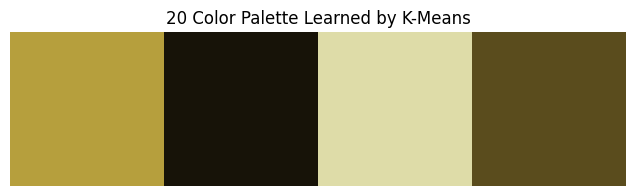

In [6]:
import matplotlib.pyplot as plt
import numpy as np

centroids = np.array(model.centroids)

palette = np.zeros((50, len(centroids) * 50, 3),
                   dtype=np.uint8)

for i, color in enumerate(centroids):

    palette[:, i*50:(i+1)*50] = color

plt.figure(figsize=(12,2))
plt.imshow(palette)
plt.axis("off")
plt.title("20 Color Palette Learned by K-Means")
plt.show()

In [7]:
unique_labels = np.unique(model.labels)

print(unique_labels)

[0 1 2 3]


In [81]:
for k in range(K):

    count = np.sum(model.labels == k)

    print(k, count)

0 1915
1 2908
2 810
3 907
4 737
5 1028
6 1545
7 3920
8 531
9 717
10 1139
11 390
12 1204
13 1097
14 1176
15 364
16 8759
17 808
18 5617
19 2060


In [82]:
dominant = np.argmax([
    np.sum(model.labels == k)
    for k in range(K)
])

print(
    "Dominant Color:",
    model.centroids[dominant]
)

Dominant Color: [8.06610344 7.22696655 4.77623016]


k=30

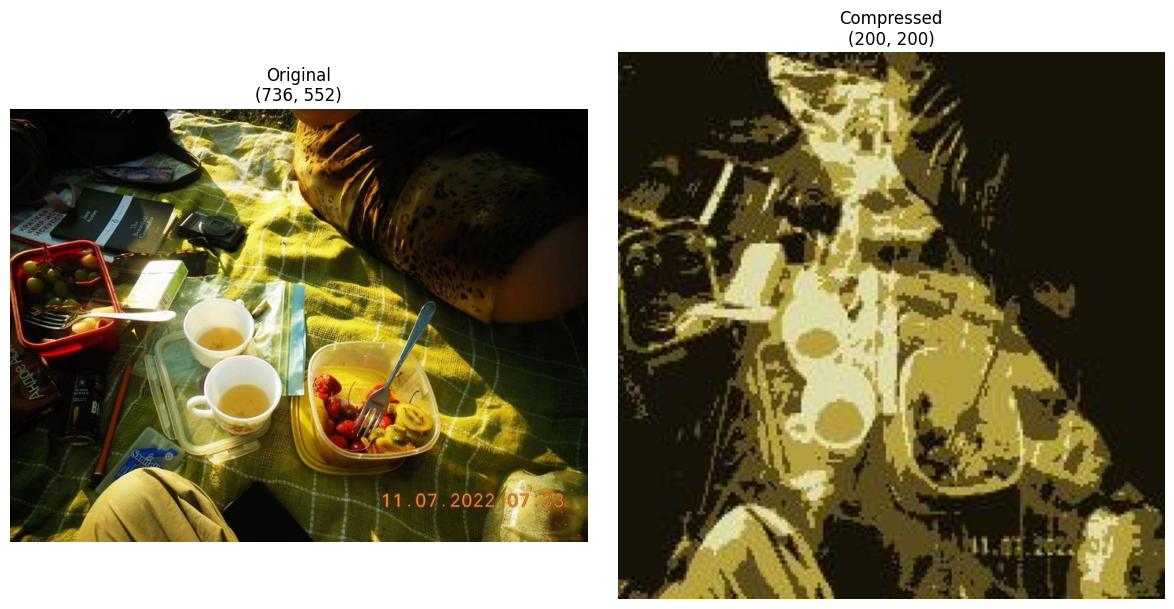

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

# Ảnh gốc
img_original = Image.open("f95aed8502aa31e208630a20b28c808c.jpg")

# Ảnh nén
img_compressed = Image.open("compressed.jpg")

plt.figure(figsize=(12, 6))

# Ảnh gốc
plt.subplot(1, 2, 1)
plt.imshow(img_original)
plt.title(f"Original\n{img_original.size}")
plt.axis("off")

# Ảnh nén
plt.subplot(1, 2, 2)
plt.imshow(img_compressed)
plt.title(f"Compressed\n{img_compressed.size}")
plt.axis("off")

plt.tight_layout()
plt.show()